# Experimento 1 - Comparacao entre politicas

Objetivo: comparar `threshold`, `on_demand` e `hybrid`, implementadas no Controller como politicas distintas de atendimento de requisicao.


In [1]:
import sys
import os
from pathlib import Path

# Garante que o root do repositório está no PYTHONPATH
repo_root = Path('/home/esdras/Wqnets/QuantumNet')
sys.path.insert(0, str(repo_root))

import pandas as pd
import matplotlib.pyplot as plt

from quantumnet.experiments import (
    DEFAULT_POLICIES,
    stable_seed,
    run_trial_from_request_schedule,
    aggregate_trials,
    write_csv,
 )

print('Imports carregados com sucesso')

Imports carregados com sucesso


## Setup fixo do experimento

Para garantir comparacao justa entre politicas:
- Mesma topologia: `Linha` com 4 nos
- Mesmos pares Alice-Bob: `(0,1)`, `(1,2)`, `(2,3)`
- Mesma carga de requisicoes por par: `[32, 48, 64, 16, 40]`
- Mesmo threshold minimo por enlace: `96` bits

A unica variavel que muda e:
- `controller.set_policy("threshold")`
- `controller.set_policy("on_demand")`
- `controller.set_policy("hybrid")`


,policy,trial,seed,total_generated_bits,total_dropped_bits,total_consumed_bits,total_requested_bits,served_requests,failed_requests,denied_requests,...,bits_available,total_requests,service_rate,denial_rate,efficiency,buffer_mean_bits,buffer_util_mean,experiment,min_threshold_bits,buffer_capacity_bits
0,hybrid,1,3920930882,440,0,440,440,12,0,3,...,0,15,0.800000,0.200000,1.000000,17.066667,0.033333,exp1,96,512
1,hybrid,2,826362891,472,0,432,432,11,0,4,...,40,15,0.733333,0.266667,0.915254,11.733333,0.022917,exp1,96,512
2,hybrid,3,3630516219,392,0,336,336,10,0,5,...,56,15,0.666667,0.333333,0.857143,12.800000,0.025000,exp1,96,512
3,hybrid,4,1969439165,416,0,360,360,10,0,5,...,56,15,0.666667,0.333333,0.865385,9.600000,0.018750,exp1,96,512
4,hybrid,5,1128037663,480,0,424,424,12,0,3,...,56,15,0.800000,0.200000,0.883333,5.333333,0.010417,exp1,96,512
5,on_demand,1,3246593231,240,0,240,240,8,0,7,...,0,15,0.533333,0.466667,1.000000,0.000000,0.000000,exp1,96,512
6,on_demand,2,3767505667,416,0,416,416,11,0,4,...,0,15,0.733333,0.266667,1.000000,0.000000,0.000000,exp1,96,512
7,on_demand,3,2658480978,288,0,288,288,8,0,7,...,0,15,0.533333,0.466667,1.000000,0.000000,0.000000,exp1,96,512
8,on_demand,4,278241479,336,0,336,336,10,0,5,...,0,15,0.666667,0.333333,1.000000,0.000000,0.000000,exp1,96,512
9,on_demand,5,3887412071,400,0,400,400,11,0,4,...,0,15,0.733333,0.266667,1.000000,0.000000,0.000000,exp1,96,512



Resumo (média ± desvio padrão)


,policy,n,service_rate_mean,service_rate_std,denial_rate_mean,denial_rate_std,buffer_util_mean_mean,buffer_util_mean_std,replenishment_events_mean,replenishment_events_std,efficiency_mean,efficiency_std
0,hybrid,5,0.733333,0.066667,0.266667,0.066667,0.022083,0.008411,9.0,2.000000,0.904223,0.058001
1,on_demand,5,0.640000,0.101105,0.360000,0.101105,0.000000,0.000000,9.6,1.516575,1.000000,0.000000
2,threshold,5,0.226667,0.167332,0.773333,0.167332,0.018750,0.015167,1.4,1.140175,0.700000,0.414997


CSVs salvos em: /home/esdras/Wqnets/QuantumNet/results/validate_5


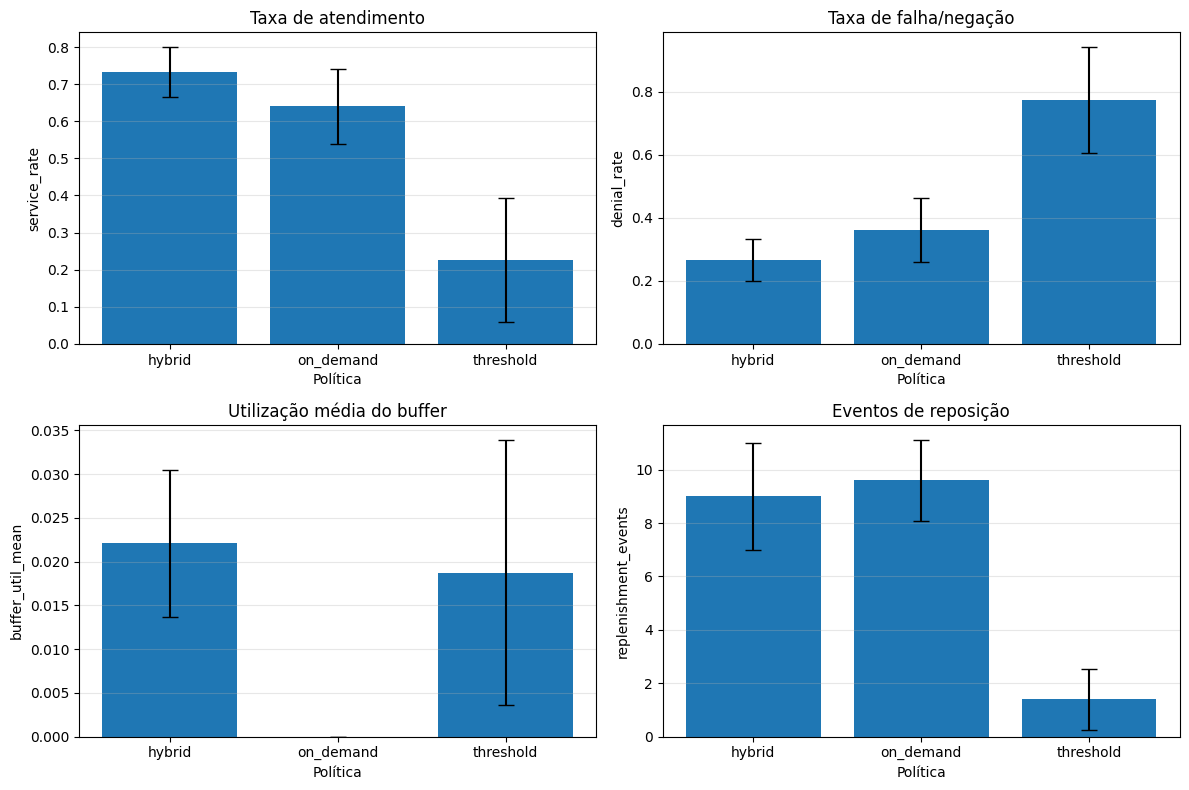

In [2]:
policies = list(DEFAULT_POLICIES)
link_pairs = [(0, 1), (1, 2), (2, 3)]

# Carga/padrão de chegada FIXO (mesmo para todas as políticas e repetições).
request_load = [32, 48, 64, 16, 40]
request_schedule = [
    (alice_id, bob_id, requested_bits)
    for (alice_id, bob_id) in link_pairs
    for requested_bits in request_load
 ]

# Parâmetros estruturais fixos
minimum_stock_bits = 96
buffer_capacity_bits = 512  # capacidade fixa do buffer por enlace (bits)

# Modo validação (rápido)
trials_per_policy = 5
base_seed = 20260326

out_dir = Path('results') / f'validate_{trials_per_policy}'
out_dir.mkdir(parents=True, exist_ok=True)

rows = []
for policy in policies:
    for trial in range(1, trials_per_policy + 1):
        row = run_trial_from_request_schedule(
            policy=policy,
            trial_id=trial,
            base_seed=base_seed,
            topology_name='Linha',
            topology_nodes=4,
            link_pairs=link_pairs,
            request_schedule=request_schedule,
            min_threshold_bits=minimum_stock_bits,
            buffer_capacity_bits=buffer_capacity_bits,
        )
        row.update({
            'experiment': 'exp1',
            'min_threshold_bits': minimum_stock_bits,
            'buffer_capacity_bits': buffer_capacity_bits,
        })
        rows.append(row)

results_df = pd.DataFrame(rows)
display(results_df.sort_values(['policy', 'trial']).reset_index(drop=True))

summary_rows = aggregate_trials(
    rows,
    group_keys=['policy'],
    metric_keys=['service_rate', 'denial_rate', 'buffer_util_mean', 'replenishment_events', 'efficiency'],
 )
summary_df = pd.DataFrame(summary_rows).sort_values(['policy']).reset_index(drop=True)

print('\nResumo (média ± desvio padrão)')
display(summary_df)

# Exporta CSVs reprodutíveis
write_csv(str(out_dir / 'exp1_trials.csv'), rows)
write_csv(str(out_dir / 'exp1_summary.csv'), summary_rows)
print(f"CSVs salvos em: {out_dir.resolve()}")

# Gráficos comparativos por política (média ± std)
metrics_to_plot = [
    ('service_rate', 'Taxa de atendimento'),
    ('denial_rate', 'Taxa de falha/negação'),
    ('buffer_util_mean', 'Utilização média do buffer'),
    ('replenishment_events', 'Eventos de reposição'),
 ]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

x = list(summary_df['policy'])
for ax, (metric, title) in zip(axes, metrics_to_plot):
    y = summary_df[f'{metric}_mean']
    yerr = summary_df[f'{metric}_std']
    ax.bar(x, y, yerr=yerr, capsize=6)
    ax.set_title(title)
    ax.set_xlabel('Política')
    ax.set_ylabel(metric)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## O que este experimento responde

A comparacao permite ver qual politica:
- atende mais requisicoes (`served_requests`);
- consome melhor o recurso-chave (`total_consumed_bits` em relacao a `total_requested_bits`);
- nega menos pedidos (`denied_requests`);
- depende mais de reposicao BB84 (`replenishment_events`).
